In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("ford.csv")

# EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [4]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(154)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

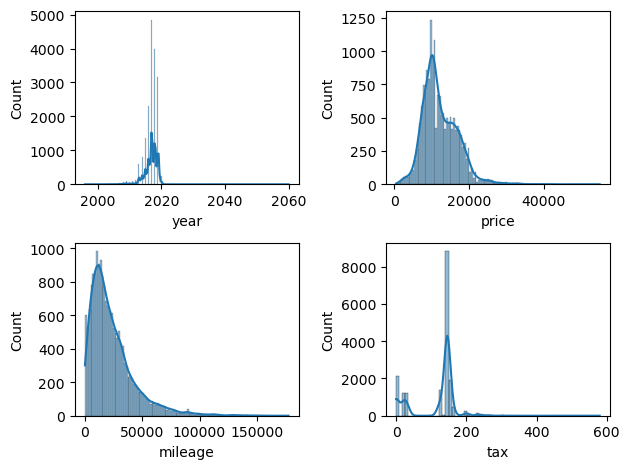

In [8]:
def plotting(var,num):
    plt.subplot(2,2,num) #matplot
    sns.histplot(df[var],kde='True')
    
plotting('year',1)
plotting('price',2)
plotting('mileage',3)
plotting('tax',4)

plt.tight_layout() 

In [9]:
price_mean = df.loc[df['price'] != 0, 'price'].mean()
# Replace 0 values with the mean
df['price'] = df['price'].replace(0,price_mean)

<Axes: >

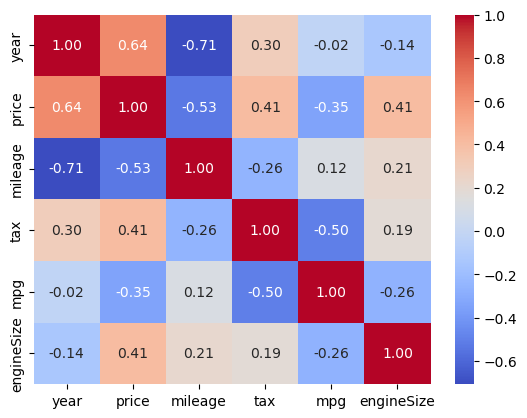

In [10]:
corr_matrix = df.corr(numeric_only=True)   # compute correlations
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

In [11]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


<Axes: xlabel='fuelType', ylabel='price'>

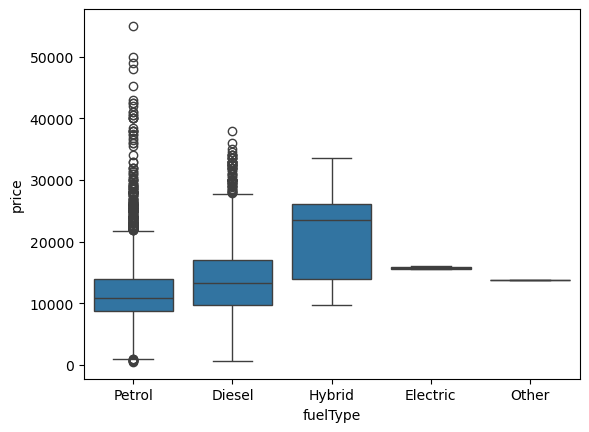

In [12]:
sns.boxplot(data=df, x='fuelType', y='price')

<Axes: xlabel='price', ylabel='tax'>

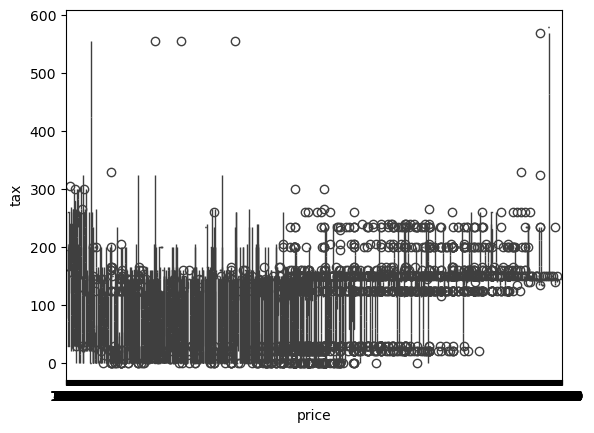

In [13]:
sns.boxplot(data=df, y='tax', x='price')

In [14]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

X = df[['model','year','transmission','fuelType','engineSize']].apply(LabelEncoder().fit_transform)
y = df['price']   # continuous

f_values, p_values = f_classif(X, y)
for col, f, p in zip(X.columns, f_values, p_values):
    decision = "Keep Feature" if p < 0.05 else "Remove Feature"
    print(f"{col}: F={f:.2f}, p={p:.4f}, {decision}")


model: F=2.03, p=0.0000, Keep Feature
year: F=12.32, p=0.0000, Keep Feature
transmission: F=1.42, p=0.0000, Keep Feature
fuelType: F=1.46, p=0.0000, Keep Feature
engineSize: F=2.62, p=0.0000, Keep Feature


# Data cleaning and preprocessing

In [15]:
# we can perform one hot encoding, for all columns at the same time
df_encode=pd.get_dummies(df,columns=['model','transmission','fuelType'],drop_first=True)

In [16]:
df_encode=df_encode.astype(int)

In [17]:
df_encode.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [18]:
# Label encoding 
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [19]:

from sklearn.preprocessing import LabelEncoder


# Columns to encode
categorical_cols = ['model', 'transmission', 'fuelType']

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
print(df.head())


   model  year  price  transmission  mileage  fuelType  tax   mpg  engineSize
0      5  2017  12000             0    15944         4  150  57.7         1.0
1      6  2018  14000             1     9083         4  150  57.7         1.0
2      6  2017  13000             1    12456         4  150  57.7         1.0
3      5  2019  17500             1    10460         4  145  40.3         1.5
4      5  2019  16500             0     1482         4  145  48.7         1.0


In [20]:
from sklearn.preprocessing import StandardScaler
columns=['model','mileage','year','fuelType','tax','mpg','engineSize']
scaler=StandardScaler()
df[columns]=scaler.fit_transform(df[columns]) #for label encoded data.

In [21]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460281,0.067059,12000,0,-0.382994,0.688206,0.591380,-0.020597,-0.810561
1,-0.210828,0.554393,14000,1,-0.736317,0.688206,0.591380,-0.020597,-0.810561
2,-0.210828,0.067059,13000,1,-0.562616,0.688206,0.591380,-0.020597,-0.810561
3,-0.460281,1.041726,17500,1,-0.665405,0.688206,0.510777,-1.737858,0.345325
4,-0.460281,1.041726,16500,0,-1.127749,0.688206,0.510777,-0.908836,-0.810561


In [22]:
from sklearn.preprocessing import StandardScaler
columns=['mileage','year','tax','mpg']
scaler=StandardScaler()
df_encode[columns]=scaler.fit_transform(df_encode[columns]) #for one hot encoded data

In [23]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

# Model

In [24]:
#label encoded data first.

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X=df.drop('price',axis=1)

In [27]:
y=df['price']

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [29]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(11934, 8) (5878, 8)
(11934,) (5878,)


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
# create a model instance
model = LinearRegression()

# fit the model on training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# make predictions on test data
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.7163583083198339

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x=df_encode.drop('price',axis=1)

In [36]:
Y=df_encode['price']

In [37]:
x_train,x_test,Y_train,Y_test=train_test_split(x,Y,test_size=0.30,random_state=42)

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
# create a model instance
model = LinearRegression()

# fit the model on training data
model.fit(x_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
Y_pred= model.predict(x_test)

In [41]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,Y_pred)
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.833120933694643